# Plot human heat stress
- This script is used to visualize metric results of human heat stress.
- Simulations: CNTL, TranAlbe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string

In [2]:
region = 'HK'
df_cntl = pd.read_csv(f'./data_for_figure/{region}_human_heat_stress_cntl.csv')
df_cntl = df_cntl.sort_values(by='time')
df_cntl

,time,HUMIDEX_U,SWBGT_U,HIA_U
0,2034-12-25 06:00:00,31.688479,26.572720,27.272498
1,2034-12-26 06:00:00,32.307128,27.158509,26.421195
2,2034-12-27 06:00:00,31.658561,26.692248,26.330806
3,2034-12-28 06:00:00,25.873610,22.995543,24.757311
4,2034-12-29 06:00:00,16.057055,16.936430,16.327145
...,...,...,...,...
1825,2039-12-25 06:00:00,31.298993,26.101020,27.825434
1826,2039-12-26 06:00:00,27.558083,23.835402,25.924278
1827,2039-12-27 06:00:00,28.915675,24.821918,25.933033
1828,2039-12-28 06:00:00,30.101384,25.323690,27.283569


In [3]:
df_tran_albe = pd.read_csv(f'./data_for_figure/{region}_human_heat_stress_tran_albe.csv')
df_tran_albe = df_tran_albe.sort_values(by='time')
df_tran_albe_merge = df_tran_albe.merge(df_cntl, on='time', suffixes=('_tran_albe', '_cntl'))
df_tran_albe_merge.head()

,time,HUMIDEX_U_tran_albe,SWBGT_U_tran_albe,HIA_U_tran_albe,HUMIDEX_U_cntl,SWBGT_U_cntl,HIA_U_cntl
0,2035-03-30 06:00:00,28.143518,24.062333,26.503883,28.153174,24.067754,26.509394
1,2035-03-31 06:00:00,22.443146,20.328529,24.850908,22.450463,20.332563,24.852829
2,2035-04-01 06:00:00,25.566731,22.197644,26.229610,25.578034,22.203992,26.236184
3,2035-04-02 06:00:00,30.999125,26.016464,27.358394,31.013970,26.024884,27.369942
4,2035-04-03 06:00:00,33.998881,27.926506,29.156620,34.008612,27.931963,29.166262


In [4]:
var_list = ['HUMIDEX_U', 'SWBGT_U', 'HIA_U']
var_name_list = ['HUMIDEX', 'sWBGT', 'NWS_HI']
var_threshold = [[30, 46], # , 54
                 [29.4, 31.1, 32.3],
                 [27, 33, 40]] # , 52
scenario_list = ['cntl', 'tran_albe']
labelcolor = '#6b6b6b'
linewidth=0.5
fontsize=6
boundarywidth=0.5
labelsize=6
length=4
pad=1
ymin_list = [5, 10, 10]
ymax_list = [55, 40,50]
xmin = pd.to_datetime("2035-01-01")
xmax = pd.to_datetime("2039-12-31")
padding = 4
handletextpad = 0.5
rolling_window = 30

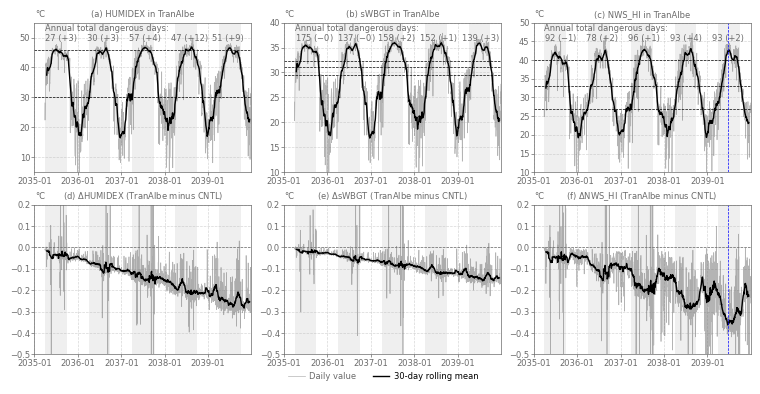

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(7.5,3.75))
ax = axes.flatten()
for i in range(6):
    var = var_list[i % 3]
    var_name = var_name_list[i % 3]
    axis_time = pd.to_datetime(df_tran_albe_merge['time'])
    mask_month = (axis_time.dt.month.isin(range(4,10)))
    if i <3:
        ymin = ymin_list[i]
        ymax = ymax_list[i]
        ax[i].plot(pd.to_datetime(df_tran_albe_merge['time']), df_tran_albe_merge[f'{var}_cntl'], 
                   linewidth=linewidth, color=labelcolor, alpha=0.5, label='Daily value')
        tran_albe_rolling = pd.Series(df_tran_albe_merge[f'{var}_tran_albe']).rolling(window=rolling_window, center=True).mean()
        ax[i].plot(pd.to_datetime(df_tran_albe_merge['time']), tran_albe_rolling, color='black', linewidth=1,
                   label=f'{rolling_window}-day rolling mean')
        threshold_list = var_threshold[i % 3]
        for threshold in threshold_list:
            ax[i].axhline(threshold, color='black', linestyle='--', linewidth=linewidth)
        title = f'({string.ascii_lowercase[i]}) {var_name} in TranAlbe' 
        for y, year in enumerate(range(2035, 2040)):
            year_start = f'{year}-01-01'
            year_end = f'{year}-12-31'
            mask_year = (pd.to_datetime(df_tran_albe_merge['time']) >= year_start) & (pd.to_datetime(df_tran_albe_merge['time']) <= year_end)
            df_year = df_tran_albe_merge[mask_year]
            last_threshold = threshold_list[-1]
            cntl_rows_exceeding = df_year[df_year[f'{var}_cntl'] >= last_threshold] 
            cntl_count_exceeding = len(cntl_rows_exceeding) 
            tran_albe_rows_exceeding = df_year[df_year[f'{var}_tran_albe'] >= last_threshold] 
            tran_albe_count_exceeding = len(tran_albe_rows_exceeding) 
            delta = cntl_count_exceeding - tran_albe_count_exceeding
            if delta>0:
                sign = '+'
            else:
                sign = r'$-$'    
            ax[i].text(0.05 + y*0.1925, 0.875, f'{tran_albe_count_exceeding} ({sign}{np.abs(delta)})', 
                       transform=ax[i].transAxes, fontsize=fontsize, color=labelcolor)
        ax[i].text(0.05, 0.945, f'Annual total dangerous days:', transform=ax[i].transAxes, fontsize=fontsize, color=labelcolor)     
        '''
        if i == 2:
            df_diff_rolling_var = pd.DataFrame({'delta': tran_albe_rolling})
            df_diff_rolling_var['time'] = df_tran_albe_merge['time']
            df_clean = df_diff_rolling_var.dropna(subset=['delta'])
            idx_max = df_clean['delta'].idxmax()
            max_row = df_clean.loc[idx_max]
            ax[i].axvline(x=pd.to_datetime(max_row['time']), color='blue', linewidth=linewidth, linestyle='--')        
        '''      
    else:  
        ymin = -0.5
        ymax = 0.2
        diff = df_tran_albe_merge[f'{var}_tran_albe'] - df_tran_albe_merge[f'{var}_cntl']
        ax[i].plot(pd.to_datetime(df_tran_albe_merge['time']), diff, linewidth=linewidth, color=labelcolor, alpha=0.5)
        diff_rolling = pd.Series(diff).rolling(window=rolling_window, center=True).mean()
        ax[i].plot(pd.to_datetime(df_tran_albe_merge['time']), diff_rolling, color='black', linewidth=1)
        title = rf'({string.ascii_lowercase[i]}) $\Delta${var_name} (TranAlbe minus CNTL)'
        ax[i].axhline(0, color=labelcolor, linewidth=linewidth, linestyle='--')
        if i == 5:
            df_diff_rolling_var = pd.DataFrame({'delta': diff_rolling})
            df_diff_rolling_var['time'] = df_tran_albe_merge['time']
            df_clean = df_diff_rolling_var.dropna(subset=['delta'])
            idx_min = df_clean['delta'].idxmin()
            min_row = df_clean.loc[idx_min]
            for i in [2, 5]:
                ax[i].axvline(x=pd.to_datetime(min_row['time']), color='blue', linewidth=linewidth, linestyle='--')
            
    ax[i].fill_between(axis_time, ymin, ymax, where=mask_month, color=labelcolor, alpha=0.1, edgecolor='none')
    ax[i].set_title(title, fontsize=fontsize, color=labelcolor, pad=padding)
    ax[i].set_ylim(ymin, ymax)
    ax[i].tick_params(axis='y', labelleft=True, labelsize=labelsize, length=length/2, pad=pad, width = boundarywidth,colors=labelcolor)
    ax[i].tick_params(axis='x', labelsize=labelsize, length=length/2, pad=pad, width = boundarywidth,colors=labelcolor)
    xticks = pd.date_range(start=xmin, end=xmax, freq="YS")
    xtick_labels = xticks.strftime("%Y-%m")
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_xticks(xticks)
    ax[i].set_xticklabels(xtick_labels)
    ax[i].set_ylabel(f'°C', labelpad=5, rotation=0, ha='center', fontsize=fontsize, color=labelcolor)
    ax[i].yaxis.set_label_coords(0.025, 1.025)
    ax[i].grid(True,linestyle='--',linewidth=0.5, alpha=0.5)
    for spine in ax[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor)
    

lines, labels = ax[0].get_legend_handles_labels()  
legend = fig.legend(lines, labels, bbox_to_anchor=(0.5, -0.01), loc='lower center', frameon=False,
                        handletextpad=handletextpad, fontsize=labelsize, ncol=2)
for i, text in enumerate(legend.get_texts()):
    text.set_color([labelcolor, 'black'][i])
plt.subplots_adjust(left=0.035, right=0.99, bottom=0.08, top=0.965, wspace=0.15, hspace=0.215) 
fig.savefig('hk_human_heat_stress.png', dpi=300)  
fig.savefig('hk_human_heat_stress.pdf', dpi=600)      

In [10]:
pd.to_datetime(df_tran_albe_merge['time'])

0      2035-03-30 06:00:00
1      2035-03-31 06:00:00
2      2035-04-01 06:00:00
3      2035-04-02 06:00:00
4      2035-04-03 06:00:00
               ...        
1730   2039-12-25 06:00:00
1731   2039-12-26 06:00:00
1732   2039-12-27 06:00:00
1733   2039-12-28 06:00:00
1734   2039-12-29 06:00:00
Name: time, Length: 1735, dtype: datetime64[ns]

# Description

In [13]:
var = 'HIA_U'
diff = df_tran_albe_merge[f'{var}_tran_albe'] - df_tran_albe_merge[f'{var}_cntl']
diff_rolling_var = pd.Series(diff).rolling(window=30, center=True).mean()
df_diff_rolling_var = pd.DataFrame({'delta': diff_rolling_var})
df_diff_rolling_var['time'] = df_tran_albe_merge['time']
df_clean = df_diff_rolling_var.dropna(subset=['delta'])
idx_min = df_clean['delta'].idxmin()
min_row = df_clean.loc[idx_min]
min_row

delta              -0.362202
time     2039-06-21 06:00:00
Name: 1543, dtype: object

In [9]:
np.round(df_tran_albe_merge[f'{var}_tran_albe'].loc[idx_min].item(), 1)

np.float64(41.9)

In [7]:
start_date = '2035-04-01'
end_date = '2039-12-30'
df_roof_albe = pd.read_csv('../urban_fraction_albedo_scenario/data_for_figure/sum_roof_albedo_area.csv')
df_roof_albe_region = df_roof_albe[df_roof_albe['domain'] == region].copy()
df_roof_albe_region_delta = df_roof_albe_region.copy()
df_roof_albe_region_delta['sum_roof_albedo_area'] = df_roof_albe_region['sum_roof_albedo_area'] - df_roof_albe_region['sum_roof_albedo_area'].iloc[0]
df_roof_albe_region_delta['time'] = pd.to_datetime(df_roof_albe_region_delta['time'])
df_roof_albe_region_delta_filtered = df_roof_albe_region_delta[(df_roof_albe_region_delta['time'] >= start_date)].copy()
df_roof_albe_region_delta_filtered.drop(columns=['domain'], inplace=True)
df_daily = df_roof_albe_region_delta_filtered.set_index('time').resample('1D').asfreq()
df_daily = df_daily.drop(pd.Timestamp('2036-02-29'), errors='ignore')
df_daily['sum_roof_albedo_area'] = df_daily['sum_roof_albedo_area'].interpolate(method='linear')
df_daily.reset_index(inplace=True)
df_daily_filtered = df_daily[(df_daily['time'] >= start_date) & (df_daily['time'] < end_date)]
df_daily_filtered

,time,sum_roof_albedo_area
0,2035-04-01,0.524120
1,2035-04-02,0.541590
2,2035-04-03,0.559061
3,2035-04-04,0.576532
4,2035-04-05,0.594002
...,...,...
1728,2039-12-25,15.474201
1729,2039-12-26,15.474201
1730,2039-12-27,15.474201
1731,2039-12-28,15.474201


In [14]:
#var = 'HIA_U'
#var = 'SWBGT_U'
var = 'HUMIDEX_U'
diff = df_tran_albe_merge[f'{var}_tran_albe'] - df_tran_albe_merge[f'{var}_cntl']
diff_rolling_var = pd.Series(diff).rolling(window=30, center=True).mean()
df_diff_rolling_var = pd.DataFrame({'delta': diff_rolling_var})
df_diff_rolling_var['time'] = df_tran_albe_merge['time']
df_diff = pd.DataFrame({f'delta_{var}': diff})
df_diff['time'] = pd.to_datetime(df_tran_albe_merge['time'])
df_diff[var] = df_tran_albe_merge[f'{var}_cntl']
df_diff_clean = df_diff[(df_diff['time'] >= start_date) & (df_diff['time'] < end_date)].copy().reset_index()
df_diff_clean[f'normalized_{var}'] = df_diff_clean[f'delta_{var}'] / df_diff_clean[var]
df_diff_clean['sum_roof_albedo_area'] = df_daily_filtered['sum_roof_albedo_area']
df_diff_clean['delta_sum_roof_albedo_area'] = df_diff_clean['sum_roof_albedo_area'] - df_diff_clean['sum_roof_albedo_area'].iloc[0]
df_diff_clean_albedo = df_diff_clean[(df_diff_clean['time'].dt.month>=4) & (df_diff_clean['time'].dt.month<=9)].copy()
df_diff_clean_albedo

,index,delta_HUMIDEX_U,time,HUMIDEX_U,normalized_HUMIDEX_U,sum_roof_albedo_area,delta_sum_roof_albedo_area
0,2,-0.011302,2035-04-01 06:00:00,25.578034,-0.000442,0.524120,0.000000
1,3,-0.014846,2035-04-02 06:00:00,31.013970,-0.000479,0.541590,0.017471
2,4,-0.009730,2035-04-03 06:00:00,34.008612,-0.000286,0.559061,0.034941
3,5,-0.012689,2035-04-04 06:00:00,35.655583,-0.000356,0.576532,0.052412
4,6,-0.011127,2035-04-05 06:00:00,37.484991,-0.000297,0.594002,0.069883
...,...,...,...,...,...,...,...
1638,1640,-0.303478,2039-09-26 06:00:00,40.914976,-0.007417,15.474201,14.950081
1639,1641,-0.302954,2039-09-27 06:00:00,39.516536,-0.007667,15.474201,14.950081
1640,1642,-0.295501,2039-09-28 06:00:00,41.091678,-0.007191,15.474201,14.950081
1641,1643,-0.216456,2039-09-29 06:00:00,43.196225,-0.005011,15.474201,14.950081


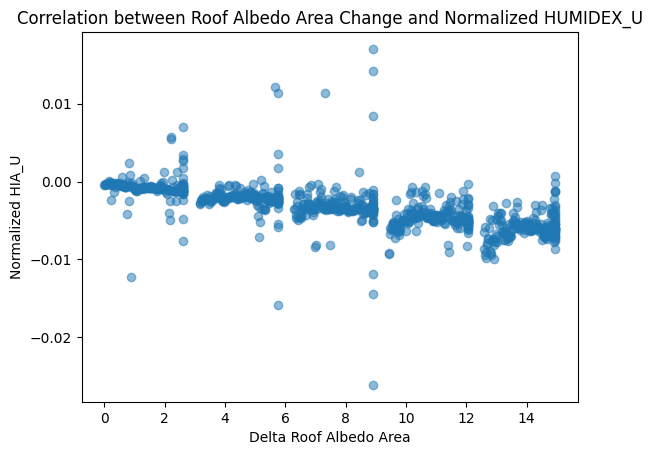

In [15]:
plt.scatter(df_diff_clean_albedo['delta_sum_roof_albedo_area'], df_diff_clean_albedo[f'normalized_{var}'], alpha=0.5)
plt.xlabel('Delta Roof Albedo Area')
plt.ylabel('Normalized HIA_U')
plt.title(f'Correlation between Roof Albedo Area Change and Normalized {var}')
plt.show()

In [16]:
corr_value = df_diff_clean_albedo['delta_sum_roof_albedo_area'].corr(df_diff_clean_albedo[f'normalized_{var}'])
print("Pearson correlation:", np.round(corr_value,2))
corr_spearman = df_diff_clean_albedo['delta_sum_roof_albedo_area'].corr(df_diff_clean_albedo[f'normalized_{var}'], method='spearman')
print("Spearman correlation:", np.round(corr_spearman,2))
x = df_diff_clean_albedo['delta_sum_roof_albedo_area']
y = df_diff_clean_albedo[f'normalized_{var}']

coeffs = np.polyfit(x, y, 1)
y_linear = np.poly1d(coeffs)(x)

r2_linear = np.corrcoef(y, y_linear)[0,1]**2
print("Linear R²:", np.round(r2_linear,2)) # r2 = pearson2

Pearson correlation: -0.63
Spearman correlation: -0.8
Linear R²: 0.4
